# 3D orthographic generation — Demo

This notebook demonstrates the voxel scene generation and orthographic projection functionality.

Core functionality has been extracted to `src/generation/`:
- `scene.py` — Scene representation, rectangular cuboid placement, ARC color palette
- `projection.py` — Orthographic projection logic
- `visualization.py` — Matplotlib visualization functions

This notebook serves as a demo and testing ground for the production code.

In [2]:
import sys
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

import numpy as np
from generation.scene import Color, build_voxel_scene
from generation.projection import get_orthographic_views
from generation.visualization import show_isometric_view, show_orthographic_views


## Reference scene first visible voxel
Ensure we all talk the same about the front, back, top, bottom, left and right orthographic views outside-in. With outside-in is a camera that looks at a orthographic side towards the center of the scene.

Use a cubical scene with a unique color at the each of 7 corners. One corner must be shifted one off to ensure it can be predicted by the right view. Provide this as an example input to LLMs.

[[[1 0 5]
  [0 0 0]
  [3 0 7]]

 [[0 0 0]
  [0 0 0]
  [4 0 0]]

 [[2 0 6]
  [0 0 0]
  [0 0 8]]]


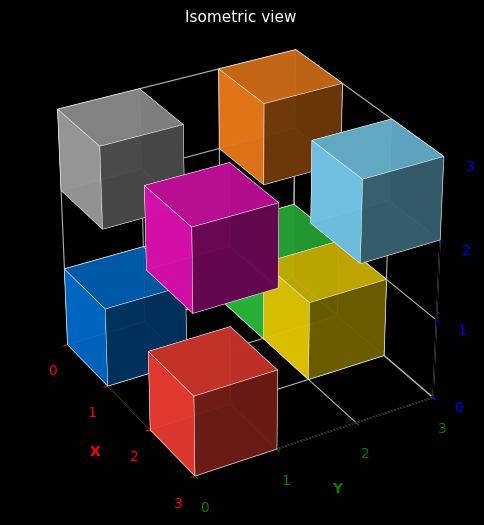

In [4]:
size = (3, 3, 3)
objects = [
    {"origin": (0, 0, 0), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.BLUE},
    {"origin": (2, 0, 0), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.RED},
    {"origin": (0, 2, 0), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.GREEN},
    {"origin": (1, 2, 0), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.YELLOW},
    {"origin": (0, 0, 2), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.GRAY},
    {"origin": (2, 0, 2), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.FUCHSIA},
    {"origin": (0, 2, 2), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.ORANGE},
    {"origin": (2, 2, 2), "shape_mask": np.ones((1, 1, 1), dtype=int), "color": Color.AZURE},
]


voxel_scene = build_voxel_scene(size, objects)
print(voxel_scene)
show_isometric_view(voxel_scene)

In [5]:
ortho_views = get_orthographic_views(voxel_scene)
#list(ortho_views.items())

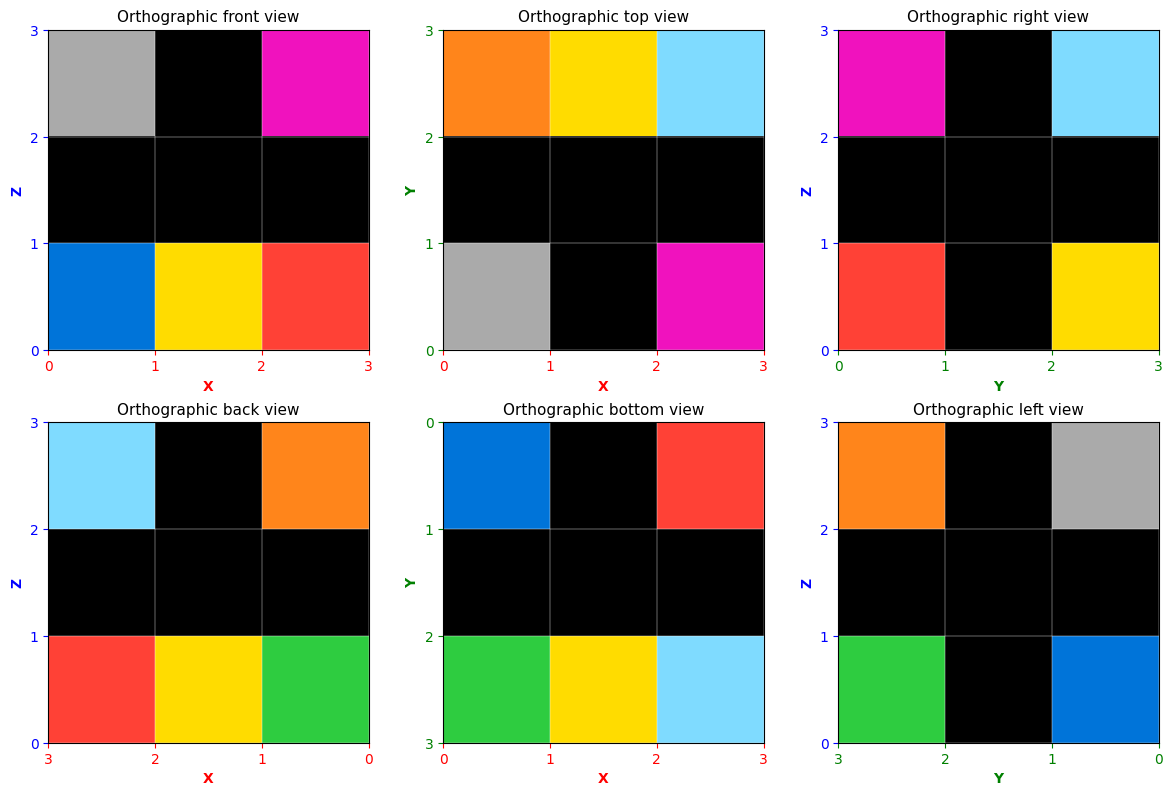

In [8]:
show_orthographic_views(ortho_views)
